# Figure 1 — Decomposition and method comparison of inferential uncertainty (B&W)

Two-panel figure for a single representative action rule from the IBM Employee
Attrition dataset (the widest-CI rule, chosen in `02_rule_level_cis.ipynb`):

* **Left panel.** The two component confidences $p_u = \mathrm{conf}(r_1)$
  (undesired side) and $p_d = \mathrm{conf}(r_2)$ (desired side) overlaid in the
  same axes — bootstrap histograms together with Wald (Normal) and Bayesian
  (Beta-Binomial posterior) density overlays. Component Wilson score 95% CIs
  are shown as thick brackets beneath the histograms. Shows where the
  inferential spread of the composite uplift comes from.
* **Right panel.** The composite uplift
  $\hat{\upsilon} = (p_u + p_d - 1) \cdot n_u / N$ with bootstrap histogram +
  Wald Normal + Bayesian density overlays, plus four 95% CI brackets beneath
  the x-axis (Bootstrap percentile, Wald, Bayesian, Newcombe-Wilson)
  demonstrating that all four article CI methods produce visually
  indistinguishable intervals on this rule.

The bootstrap and Bayesian samples are re-derived locally in this notebook
from the four boolean masks (`u_ante`, `u_match`, `d_ante`, `d_match`) stored
in `article/results/rule_level_bootstrap_samples.npz`; this replicates the
engine's nonparametric resampling exactly (`bootstrap.py:426-445`,
`bayesian.py:154-170`).

**Output:** `article/figures/fig1_bootstrap_distribution.pdf`.

In [1]:
from __future__ import annotations
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import norm, beta as beta_dist, gaussian_kde
REPO = Path.cwd()
while not (REPO / 'pyproject.toml').exists() and REPO != REPO.parent:
    REPO = REPO.parent
if str(REPO / 'notebooks' / 'article' / 'figures') not in sys.path:
    sys.path.insert(0, str(REPO / 'notebooks' / 'article' / 'figures'))
from _style import DOUBLE_COL_INCHES, apply_rc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
apply_rc()
NPZ = REPO / 'article' / 'results' / 'rule_level_bootstrap_samples.npz'
CSV = REPO / 'article' / 'results' / 'rule_level_cis.csv'
PDF = REPO / 'article' / 'figures' / 'fig1_bootstrap_distribution.pdf'

# ----------------------------------------------------------------------------
# Sufficient statistics for the Attrition widest-CI rule, saved by 02_rule_*.
# Boolean masks (uint8) let us replicate the engine's nonparametric bootstrap
# (index resampling + recount) and the Beta-Binomial posterior for the
# components p_u and p_d.
# ----------------------------------------------------------------------------
data = np.load(NPZ)
u_ante = data['attrition_rule_u_ante'].astype(bool)
u_match = data['attrition_rule_u_match'].astype(bool)
d_ante = data['attrition_rule_d_ante'].astype(bool)
d_match = data['attrition_rule_d_match'].astype(bool)
N = int(data['attrition_rule_N'][0])
rule_idx = int(data['attrition_rule_index'][0])
boot_point = float(data['attrition_rule_point'][0])
boot_ci = data['attrition_rule_ci']

n_u_full = int(u_ante.sum())
n_u_match_full = int(u_match.sum())
n_d_full = int(d_ante.sum())
n_d_match_full = int(d_match.sum())
p_u_hat = n_u_match_full / n_u_full if n_u_full > 0 else 0.0
p_d_hat = n_d_match_full / n_d_full if n_d_full > 0 else 0.0
d_hat = p_u_hat + p_d_hat - 1.0
uplift_hat = d_hat * (n_u_full / N)
print(f'rule_idx={rule_idx}  N={N}  n_u={n_u_full}  n_u_match={n_u_match_full}  p_u_hat={p_u_hat:.4f}')
print(f'                     n_d={n_d_full}  n_d_match={n_d_match_full}  p_d_hat={p_d_hat:.4f}')
print(f'                     d_hat={d_hat:.4f}  uplift_hat={uplift_hat:.5f}  bootstrap_CI={boot_ci.round(5).tolist()}')

# ----------------------------------------------------------------------------
# Wald / Wilson / Bayesian CI brackets for the composite uplift -- from CSV.
# ----------------------------------------------------------------------------
ci_df = pd.read_csv(CSV)
ci_df = ci_df[(ci_df['dataset'] == 'IBM Employee Attrition') & (ci_df['rule_index'] == rule_idx)]
def _ci(method):
    row = ci_df[ci_df['method'] == method].iloc[0]
    return float(row['uplift_point']), float(row['uplift_ci_lower']), float(row['uplift_ci_upper'])
wald_pt, wald_lo, wald_hi = _ci('wald')
wilson_pt, wilson_lo, wilson_hi = _ci('wilson')
bayes_pt, bayes_lo, bayes_hi = _ci('bayesian')
se_wald = (wald_hi - wald_lo) / (2.0 * norm.ppf(0.975))
print(f'Wald CI=[{wald_lo:.5f}, {wald_hi:.5f}]  SE_Wald={se_wald:.5f}')
print(f'Wilson CI=[{wilson_lo:.5f}, {wilson_hi:.5f}]  Bayes CI=[{bayes_lo:.5f}, {bayes_hi:.5f}]')

# ----------------------------------------------------------------------------
# Wilson 95% CIs for the COMPONENT proportions p_u and p_d.  These are not in
# the CSV (CSV stores composite uplift CIs only), so we compute them here.
# Wilson score interval: center = (p_hat + z^2 / (2n)) / (1 + z^2/n);
#                        half = z * sqrt(p_hat(1-p_hat)/n + z^2/(4n^2)) / (1 + z^2/n).
# ----------------------------------------------------------------------------
def wilson_ci(p_hat, n, conf=0.95):
    z = norm.ppf(0.5 + conf / 2.0)
    denom = 1.0 + z * z / n
    center = (p_hat + z * z / (2.0 * n)) / denom
    half = z * np.sqrt(p_hat * (1 - p_hat) / n + z * z / (4.0 * n * n)) / denom
    return center - half, center + half

p_u_wilson_lo, p_u_wilson_hi = wilson_ci(p_u_hat, n_u_full)
p_d_wilson_lo, p_d_wilson_hi = wilson_ci(p_d_hat, n_d_full)
print(f'Wilson p_u CI=[{p_u_wilson_lo:.4f}, {p_u_wilson_hi:.4f}]   p_d CI=[{p_d_wilson_lo:.4f}, {p_d_wilson_hi:.4f}]')

# ----------------------------------------------------------------------------
# Local resampling.  Bootstrap replicates the engine's index-with-replacement
# nonparametric scheme; Bayesian draws are from independent Beta posteriors.
# ----------------------------------------------------------------------------
SEED = 42
N_BOOTSTRAP = 500
N_MC = 10000

rng = np.random.default_rng(SEED)
p_u_boot = np.empty(N_BOOTSTRAP)
p_d_boot = np.empty(N_BOOTSTRAP)
uplift_boot = np.empty(N_BOOTSTRAP)
p_u_boot[:] = np.nan
p_d_boot[:] = np.nan
uplift_boot[:] = np.nan
for b in range(N_BOOTSTRAP):
    idx = rng.integers(0, N, size=N)
    nu_a = int(u_ante[idx].sum()); nu_m = int(u_match[idx].sum())
    nd_a = int(d_ante[idx].sum()); nd_m = int(d_match[idx].sum())
    if nu_a == 0 or nd_a == 0:
        continue
    pu_b = nu_m / nu_a
    pd_b = nd_m / nd_a
    p_u_boot[b] = pu_b
    p_d_boot[b] = pd_b
    uplift_boot[b] = (pu_b + pd_b - 1.0) * (nu_a / N)

# Bayesian: uniform Beta(1, 1) prior, conjugate update.
alpha_u, beta_u = 1 + n_u_match_full, 1 + (n_u_full - n_u_match_full)
alpha_d, beta_d = 1 + n_d_match_full, 1 + (n_d_full - n_d_match_full)
p_u_bayes = rng.beta(alpha_u, beta_u, size=N_MC)
p_d_bayes = rng.beta(alpha_d, beta_d, size=N_MC)
uplift_bayes = (p_u_bayes + p_d_bayes - 1.0) * (n_u_full / N)
print(f'Bayesian posterior:  p_u ~ Beta({alpha_u}, {beta_u})   p_d ~ Beta({alpha_d}, {beta_d})')
print(f'Bootstrap NaN count: {np.isnan(uplift_boot).sum()} / {N_BOOTSTRAP}')

rule_idx=1  N=1470  n_u=49  n_u_match=32  p_u_hat=0.6531
                     n_d=104  n_d_match=83  p_d_hat=0.7981
                     d_hat=0.4511  uplift_hat=0.01504  bootstrap_CI=[0.00991, 0.02219]
Wald CI=[0.00990, 0.02017]  SE_Wald=0.00262
Wilson CI=[0.00932, 0.01931]  Bayes CI=[0.00953, 0.01953]
Wilson p_u CI=[0.5131, 0.7708]   p_d CI=[0.7110, 0.8640]
Bayesian posterior:  p_u ~ Beta(33, 18)   p_d ~ Beta(84, 22)
Bootstrap NaN count: 0 / 500


wrote article\figures\fig1_bootstrap_distribution.pdf


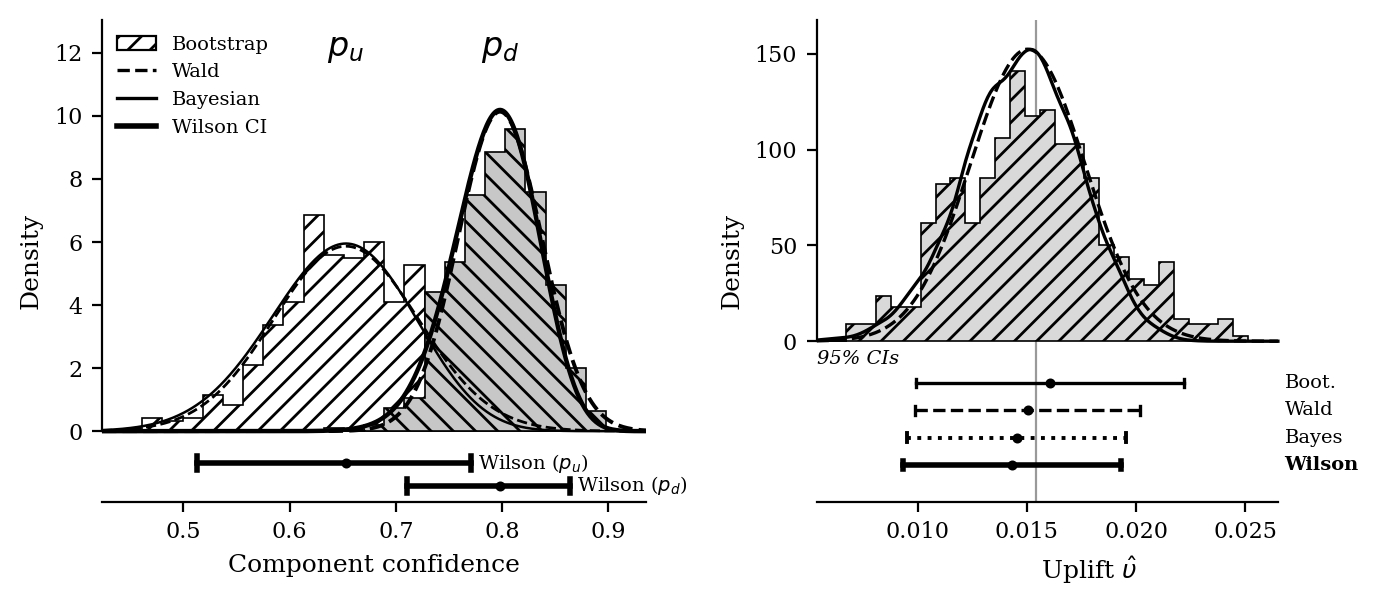

In [2]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(DOUBLE_COL_INCHES, 3.1))

# ============================================================================
# LEFT PANEL -- two component distributions p_u and p_d overlaid.
# ============================================================================
p_u_clean = p_u_boot[~np.isnan(p_u_boot)]
p_d_clean = p_d_boot[~np.isnan(p_d_boot)]
lo_x = max(min(p_u_clean.min(), p_d_clean.min(),
               p_u_wilson_lo, p_d_wilson_lo) - 0.04, 0.0)
hi_x = min(max(p_u_clean.max(), p_d_clean.max(),
               p_u_wilson_hi, p_d_wilson_hi) + 0.04, 1.0)
xL = np.linspace(lo_x, hi_x, 400)

bins_L = np.linspace(lo_x, hi_x, 28)
axL.hist(p_u_clean, bins=bins_L, density=True, histtype='stepfilled',
         facecolor='white', edgecolor='black', linewidth=0.6,
         hatch='///', alpha=1.0, zorder=2)
axL.hist(p_d_clean, bins=bins_L, density=True, histtype='stepfilled',
         facecolor='0.78', edgecolor='black', linewidth=0.6,
         hatch='\\\\\\', alpha=1.0, zorder=2)

# Wald (Normal) curves -- variance = p(1-p)/n.
se_p_u = np.sqrt(p_u_hat * (1 - p_u_hat) / n_u_full)
se_p_d = np.sqrt(p_d_hat * (1 - p_d_hat) / n_d_full)
axL.plot(xL, norm.pdf(xL, p_u_hat, se_p_u), color='black', linestyle='--',
         linewidth=1.0, zorder=4)
axL.plot(xL, norm.pdf(xL, p_d_hat, se_p_d), color='black', linestyle='--',
         linewidth=1.4, zorder=4)

# Bayesian Beta posteriors (exact PDFs).
axL.plot(xL, beta_dist.pdf(xL, alpha_u, beta_u), color='black', linestyle='-',
         linewidth=0.9, zorder=5)
axL.plot(xL, beta_dist.pdf(xL, alpha_d, beta_d), color='black', linestyle='-',
         linewidth=1.6, zorder=5)

axL.set_xlabel('Component confidence')
axL.set_ylabel('Density')

y_max_L = max(
    beta_dist.pdf(p_u_hat, alpha_u, beta_u),
    beta_dist.pdf(p_d_hat, alpha_d, beta_d),
    norm.pdf(p_u_hat, p_u_hat, se_p_u),
    norm.pdf(p_d_hat, p_d_hat, se_p_d),
)
# Reserve headroom for component labels and a footer area for Wilson brackets.
axL.set_xlim(lo_x, hi_x)
axL.set_ylim(-0.22 * y_max_L, y_max_L * 1.28)

axL.text(p_u_hat, y_max_L * 1.14, r'$p_u$',
         ha='center', va='bottom', fontsize=12, fontweight='bold')
axL.text(p_d_hat, y_max_L * 1.14, r'$p_d$',
         ha='center', va='bottom', fontsize=12, fontweight='bold')

# Wilson 95% CI brackets at the bottom -- one per component.
wilson_lw = 2.0
wilson_baseline_u = -0.10 * y_max_L
wilson_baseline_d = -0.17 * y_max_L
cap_h = 0.022 * y_max_L
for (lo, hi, p_hat, y_b, lbl) in [
    (p_u_wilson_lo, p_u_wilson_hi, p_u_hat, wilson_baseline_u, r'Wilson ($p_u$)'),
    (p_d_wilson_lo, p_d_wilson_hi, p_d_hat, wilson_baseline_d, r'Wilson ($p_d$)'),
]:
    axL.plot([lo, hi], [y_b, y_b], color='black', linestyle='-',
             linewidth=wilson_lw, clip_on=False, zorder=6)
    axL.plot([lo, lo], [y_b - cap_h, y_b + cap_h], color='black',
             linewidth=wilson_lw, clip_on=False, zorder=6)
    axL.plot([hi, hi], [y_b - cap_h, y_b + cap_h], color='black',
             linewidth=wilson_lw, clip_on=False, zorder=6)
    axL.plot(p_hat, y_b, marker='o', color='black', markersize=2.6,
             clip_on=False, zorder=7)
    axL.text(hi + (hi_x - lo_x) * 0.012, y_b, lbl, va='center', ha='left',
             fontsize=7, clip_on=False)

# Hide the negative y-axis spine; keep only non-negative ticks.
axL.spines['left'].set_bounds(0, y_max_L * 1.28)
axL.set_yticks([t for t in axL.get_yticks() if 0 <= t <= y_max_L * 1.28 + 1e-9])

import matplotlib.patches as mpatches
legend_L_handles = [
    mpatches.Patch(facecolor='white', edgecolor='black', hatch='///',
                   label='Bootstrap'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=1.2, label='Wald'),
    Line2D([0], [0], color='black', linestyle='-', linewidth=1.2, label='Bayesian'),
    Line2D([0], [0], color='black', linestyle='-', linewidth=2.0, label='Wilson CI'),
]
axL.legend(handles=legend_L_handles, loc='upper left', fontsize=7, frameon=False,
           handlelength=2.0, borderaxespad=0.4)

# ============================================================================
# RIGHT PANEL -- composite uplift with multi-method overlay + CI brackets.
# ============================================================================
uplift_clean = uplift_boot[~np.isnan(uplift_boot)]
lo_xR = min(uplift_clean.min(), wald_lo, wilson_lo, bayes_lo) - 0.002
hi_xR_data = max(uplift_clean.max(), wald_hi, wilson_hi, bayes_hi) + 0.002

bins_R = np.linspace(lo_xR, hi_xR_data, 32)
axR.hist(uplift_clean, bins=bins_R, density=True, histtype='stepfilled',
         facecolor='0.85', edgecolor='black', linewidth=0.6, hatch='///',
         alpha=1.0, zorder=2)

xR = np.linspace(lo_xR, hi_xR_data, 400)
axR.plot(xR, norm.pdf(xR, wald_pt, se_wald), color='black', linestyle='--',
         linewidth=1.2, zorder=4)

# Bayesian posterior density: smoothed kernel density estimate over the
# 10,000 Monte Carlo draws from (p_u + p_d - 1) * n_u/N.  The composite has
# no closed-form density (convolution of two scaled Beta distributions), so
# a smoothed KDE is the appropriate non-parametric estimate -- much cleaner
# than a raw histogram outline.
kde = gaussian_kde(uplift_bayes, bw_method='scott')
axR.plot(xR, kde(xR), color='black', linestyle='-', linewidth=1.2, zorder=5)

axR.axvline(boot_point, color='black', linestyle='-', linewidth=0.8, alpha=0.4,
            zorder=1)

axR.set_xlabel(r'Uplift $\hat{\upsilon}$')
axR.set_ylabel('Density')

y_top_R = max(kde(xR).max(),
              norm.pdf(wald_pt, wald_pt, se_wald),
              np.histogram(uplift_clean, bins=bins_R, density=True)[0].max())
y_top_R *= 1.10
axR.set_ylim(-0.50 * y_top_R, y_top_R)

hi_xR_full = hi_xR_data + (hi_xR_data - lo_xR) * 0.18
axR.set_xlim(lo_xR, hi_xR_full)

bracket_specs = [
    ('Boot.',    float(boot_ci[0]),  float(boot_ci[1]),  '-',  1.2, 'normal'),
    ('Wald',     wald_lo,            wald_hi,            '--', 1.2, 'normal'),
    ('Bayes',    bayes_lo,           bayes_hi,           ':',  1.4, 'normal'),
    ('N-Wilson', wilson_lo,          wilson_hi,          '-',  2.0, 'bold'),
]
row_height = 0.085 * y_top_R
bracket_baseline = -0.13 * y_top_R
label_x = hi_xR_data + (hi_xR_full - hi_xR_data) * 0.08
for k, (lbl, lo, hi, ls, lw, wt) in enumerate(bracket_specs):
    y = bracket_baseline - k * row_height
    mid = 0.5 * (lo + hi)
    axR.plot([lo, hi], [y, y], color='black', linestyle=ls, linewidth=lw,
             clip_on=False, zorder=6)
    axR.plot([lo, lo], [y - row_height * 0.16, y + row_height * 0.16],
             color='black', linewidth=lw, clip_on=False, zorder=6)
    axR.plot([hi, hi], [y - row_height * 0.16, y + row_height * 0.16],
             color='black', linewidth=lw, clip_on=False, zorder=6)
    axR.plot(mid, y, marker='o', color='black', markersize=2.6,
             clip_on=False, zorder=7)
    axR.text(label_x, y, lbl, va='center', ha='left',
             fontsize=7, fontweight=wt, clip_on=False)

axR.text(lo_xR, bracket_baseline + row_height * 0.55, '95% CIs',
         va='bottom', ha='left', fontsize=7, fontstyle='italic')

axR.spines['left'].set_bounds(0, y_top_R)
axR.set_yticks([t for t in axR.get_yticks() if 0 <= t <= y_top_R + 1e-9])
axR.spines['bottom'].set_bounds(lo_xR, hi_xR_data)
axR.set_xticks([t for t in axR.get_xticks() if lo_xR - 1e-9 <= t <= hi_xR_data + 1e-9])

fig.tight_layout()
fig.savefig(PDF, format='pdf', bbox_inches='tight')
print('wrote', PDF.relative_to(REPO))
plt.show()